## About this fork

This private notebook continues other people's public work, then adds a policy change we measured on the leaderboard.

**Whose work we continue**

- [Tufa Labs Duck harness — June 30 milestone winner](https://www.kaggle.com/code/jeroencottaar/tufa-labs-duck-harness-june-30-milestone-winner) by Jeroen Cottaar and the Tufa Labs team (Harold Bessis, Isaiah Pressman, Andries Smit, Michal Tesnar, Stefano Viel). The Duck prompts, tool-use loop, game policy, and scorer are theirs. Their public writeup discusses a milestone score of 1.21 on *their* original notebook; that result is not ours and is not claimed here.
- [Keith Tyser's Flash NVFP4 serving fork](https://www.kaggle.com/code/keithtyser/duck-qwen3-8-flash-next-nvfp4-mtp): pinned `keithtyser/qwen3-8-flash-next-nvfp4` (RadixArk / ModelOpt NVFP4, MTP3, offline vLLM, RTX Pro 6000). That fork is serving and runtime, not a new Duck policy.

**What we added**

- **S4** — ignore the top two HUD rows when deciding whether an action changed the interior; after two confirmed no-interior-change repeats of the same `(semantic state, action)`, tell the model. No global action ban. Reset on level change. Public **3.70**; retained here.
- **S4b** — same guard with top **and** bottom two HUD rows. Public **2.77**; rejected (−0.93 vs S4). Not stacked.
- **This notebook (S6)** — keep the last **8 assistant turns** instead of Duck's 30; when older turns are dropped, fold labeled facts into verified world/goal/action memory, disproved hypotheses, open questions, and the current plan. S4 top-HUD no-impact stays. S1/S2/S3/S4b are not stacked.

**Scores (our account, Public LB)**

| Notebook | Public |
|---|---:|
| Tufa Duck original (their public notebooks) | their milestone writeup, not this fork |
| Our Flash NVFP4 serving-only (kernel v3) | 3.39, unlucky repeat 2.95 |
| S1 / S2 / S3 policy tries | 2.71 / 2.72 / 2.77 — rejected, not stacked |
| S4 top-HUD no-impact (kernel v7) | **3.70** (working champion) |
| S4b outer HUD (kernel v9) | 2.77 — rejected |
| This notebook (S6 scheduled simplification) | not yet submitted |

Public scores on this competition are noisy (same Flash v3 moved 3.39 ↔ 2.95). Treat a single delta as a signal, not a proof. Code from Tufa/Keith remains with credit; the commentary in this notebook is ours.


# ARC-AGI-3 — scheduled simplification on Flash NVFP4

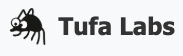

Private competition notebook for **ARC Prize 2026 / ARC-AGI-3**. Internet is off. Select GPU **RTX Pro 6000** if you copy the kernel.

The attached solver is Tufa Labs' Duck harness. The serving stack is Keith Tyser's Qwen3.8-Flash-Next NVFP4 port. Tufa's forum writeup is [discussion 717133](https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133); the [MLST interview](https://x.com/MLStreetTalk/status/2072326433922297975?s=20) is about *their* harness, not this fork.

This notebook installs the ARC runtime from the competition wheelhouse, imports the bundled Duck snapshot, loads the pickled benchmark, plays the games, and writes `/kaggle/working`. A real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) uses production budgets and the live Arcade. An interactive Save & Run is a **short smoke** (two public games, capped actions) so we can confirm the checkpoint loads without burning the 9-hour hidden rerun.

**Policy in this version.** S4 top-HUD no-impact is retained. On top of that, persistent chat history is capped at eight assistant turns; dropped turns are compacted into structured memory instead of remaining as a long REPL dump.

Solver code lives in the attached dataset; this notebook is the Kaggle wrapper plus our S4 guard and S6 simplification hook.


## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.


In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# Skip periodic JSON/HTML diagnostics and per-frame logging for every run.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1"

# Apply the measured vLLM winner before any serving setup command runs.
PUBLIC25_VLLM_PROFILE_NAME = 'kv5-bf16-mtp3-c8-cg32'
PUBLIC25_VLLM_PROFILE_ENV = {
    "TAAF_VLLM_ENABLE_PREFIX_CACHING": "0",
    "TAAF_VLLM_KV_CACHE_DTYPE": "auto",
    "TAAF_VLLM_KV_CACHE_MEMORY_BYTES": "5368709120",
    "TAAF_VLLM_MAX_CUDAGRAPH_CAPTURE_SIZE": "32",
    "TAAF_VLLM_MAX_NUM_BATCHED_TOKENS": "8192",
    "TAAF_VLLM_MAX_NUM_SEQS": "8",
    "TAAF_VLLM_MTP_TOKENS": "3",
    "TAAF_VLLM_OMP_THREADS": "1"
}
for key, value in PUBLIC25_VLLM_PROFILE_ENV.items():
    os.environ[key] = value
print(
    f'PUBLIC25_VLLM_PROFILE name={PUBLIC25_VLLM_PROFILE_NAME} '
    f'env={json.dumps(PUBLIC25_VLLM_PROFILE_ENV, sort_keys=True)}',
    flush=True,
)
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

def _competition_root():
    candidates = [
        Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3"),
        Path("/kaggle/input/arc-prize-2026-arc-agi-3"),
    ]
    for root in candidates:
        if (root / "arc_agi_3_wheels").exists():
            print(f"taaf.kaggle: competition root = {root}")
            return root
    for wheels in Path("/kaggle/input").rglob("arc_agi_3_wheels"):
        if wheels.is_dir():
            print(f"taaf.kaggle: competition root = {wheels.parent}")
            return wheels.parent
    raise RuntimeError("Competition dataset with arc_agi_3_wheels was not mounted under /kaggle/input")

COMPETITION_ROOT = _competition_root()


## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).


In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        str(COMPETITION_ROOT / "arc_agi_3_wheels"),
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.


In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["keithtyser/duck-qwen38-nvfp4-mtp-vllm-smoke-v1", "keithtyser/qwen38-flash-next-vllm-nvfp4-runtime-v1"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.


In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.


In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Solver settings, the retained S4 top-HUD no-impact guard, and S6 scheduled transcript
simplification are applied here after the bundled Duck runtime has loaded. Production budgets
stay on the competition rerun; Save & Run stays a short smoke.


In [ ]:


# === S6 scheduled simplification on S4 parent ===
# Packaging: competition rerun keeps production budgets. Offline Save & Run is a
# short smoke. Retained policy: S4 top-HUD no-impact (hud_bottom_rows=0).
# New causal change: S6 8-turn history + dropped-transcript compaction.
# S1/S2/S3/S4b not stacked. Parent is S4 kernel v7 / Public 3.70.
P0_SOURCE = r'''"""P0a: short Kaggle Phase A smoke vs unchanged competition rerun.

Packaging only. Production/TRUE_SUBMISSION budgets stay exactly the Flash v3
values. Offline Save & Run uses a short 1-2 game smoke so Kaggle GPU time is
minutes, not a full public-25. Hidden rerun is selected solely by
``KAGGLE_IS_COMPETITION_RERUN`` and never inherits smoke caps.
"""

from __future__ import annotations

from typing import Any, Sequence

PRODUCTION_MAX_RUNTIME_S_PER_GAME = 7920.0
PRODUCTION_ANALYZER_TIMEOUT_S = 900.0
PRODUCTION_CONCURRENCY = 28
PRODUCTION_MAX_ACTIONS_PER_GAME = None
PRODUCTION_NOTEBOOK_BUDGET_S = 32400.0
PRODUCTION_PUBLIC_GAMES = 25

SMOKE_MAX_RUNTIME_S_PER_GAME = 180.0
SMOKE_ANALYZER_TIMEOUT_S = 120.0
SMOKE_CONCURRENCY = 2
SMOKE_MAX_ACTIONS_PER_GAME = 4
SMOKE_GAME_COUNT = 2

MODE_COMPETITION = "competition"
MODE_KAGGLE_SMOKE = "kaggle_smoke"
MODE_OFFLINE_EVAL = "offline_eval"


def phase_a_mode(*, true_submission: bool, offline_eval: bool = False) -> str:
    if true_submission:
        return MODE_COMPETITION
    if offline_eval:
        return MODE_OFFLINE_EVAL
    return MODE_KAGGLE_SMOKE


def apply_solver_settings(
    bm: Any,
    target: Any,
    *,
    true_submission: bool,
    offline_eval: bool = False,
) -> str:
    mode = phase_a_mode(true_submission=true_submission, offline_eval=offline_eval)
    if float(getattr(target, "max_runtime_s", 0.0) or 0.0) != PRODUCTION_NOTEBOOK_BUDGET_S:
        raise RuntimeError(
            f"Expected the {PRODUCTION_NOTEBOOK_BUDGET_S:.0f}-second notebook budget, "
            f"got {getattr(target, 'max_runtime_s', None)!r}."
        )
    if mode == MODE_KAGGLE_SMOKE:
        bm.solver.max_runtime_s_per_game = SMOKE_MAX_RUNTIME_S_PER_GAME
        bm.solver.analyzer_timeout = SMOKE_ANALYZER_TIMEOUT_S
        bm.solver.concurrency = SMOKE_CONCURRENCY
        bm.solver.max_actions_per_game = SMOKE_MAX_ACTIONS_PER_GAME
    else:
        bm.solver.max_runtime_s_per_game = PRODUCTION_MAX_RUNTIME_S_PER_GAME
        bm.solver.analyzer_timeout = PRODUCTION_ANALYZER_TIMEOUT_S
        bm.solver.concurrency = PRODUCTION_CONCURRENCY
        bm.solver.max_actions_per_game = PRODUCTION_MAX_ACTIONS_PER_GAME
    bm.solver.save_request_logs = False
    print(
        f"PHASE_A_MODE mode={mode} budget_s={bm.solver.max_runtime_s_per_game} "
        f"concurrency={bm.solver.concurrency} analyzer_timeout={bm.solver.analyzer_timeout} "
        f"action_cap={bm.solver.max_actions_per_game}",
        flush=True,
    )
    return mode


def select_offline_game_ids(public_ids: Sequence[str], *, mode: str) -> list[str]:
    ids = list(public_ids)
    if len(ids) != PRODUCTION_PUBLIC_GAMES:
        raise RuntimeError(f"Expected {PRODUCTION_PUBLIC_GAMES} public IDs, got {len(ids)}.")
    if mode == MODE_KAGGLE_SMOKE:
        return ids[:SMOKE_GAME_COUNT]
    return ids


def require_model_actions(total_actions: int, *, mode: str) -> None:
    if total_actions <= 0:
        raise RuntimeError(
            f"Phase A mode={mode} produced no actions; refusing empty smoke/eval placeholder."
        )


def should_run_public25_audit(mode: str) -> bool:
    return mode == MODE_OFFLINE_EVAL
'''
S4_SOURCE = r'''"""S4 semantic no-impact guard: HUD-insensitive repeats, not a global ban.

Single causal change: compare frames after stripping the top HUD strip, remember
``(semantic_state, action)`` only after a confirmed no-interior-change repeat,
and tell the model. Real interior motion and animations are not banned.
"""

from __future__ import annotations

import hashlib
import json
import threading
import time
from pathlib import Path
from typing import Any, Callable

S4_EXPERIMENT_ID = "S4"
S4_TELEMETRY_NAME = "s4_telemetry.json"
S4_PATCH_FLAG = "_arc_s4_patched"
HUD_TOP_ROWS = 2
HUD_BOTTOM_ROWS = 0  # S4 default: top strip only. S4b sets 2 via set_hud_bottom_rows.
CONFIRM_REPEATS = 2

Grid = list[list[int]]

_LOCK = threading.Lock()
_HUD = {"top_rows": HUD_TOP_ROWS, "bottom_rows": HUD_BOTTOM_ROWS}
_COUNTERS = {
    "transitions": 0,
    "identical": 0,
    "hud_only": 0,
    "real_change": 0,
    "confirmed_no_impact": 0,
}


def parse_grid(value: Any) -> Grid | None:
    if value is None:
        return None
    if isinstance(value, dict) and "grid" in value:
        value = value["grid"]
    rows: Grid = []
    if isinstance(value, str):
        for line in value.splitlines():
            stripped = line.strip()
            if not stripped:
                continue
            rows.append([int(ch) if ch.isdigit() else ord(ch) % 16 for ch in stripped])
    else:
        try:
            for row in value:
                rows.append([int(cell) for cell in row])
        except (TypeError, ValueError):
            return None
    if not rows or not rows[0]:
        return None
    width = len(rows[0])
    if any(len(row) != width for row in rows):
        return None
    return rows


def set_hud_bottom_rows(bottom_rows: int) -> None:
    if bottom_rows < 0:
        raise ValueError("bottom_rows must be >= 0")
    with _LOCK:
        _HUD["bottom_rows"] = int(bottom_rows)


def current_hud_bottom_rows() -> int:
    with _LOCK:
        return int(_HUD["bottom_rows"])


def strip_hud(
    grid: Grid,
    *,
    top_rows: int | None = None,
    bottom_rows: int | None = None,
) -> Grid:
    top = HUD_TOP_ROWS if top_rows is None else top_rows
    bottom = current_hud_bottom_rows() if bottom_rows is None else bottom_rows
    if len(grid) <= top + bottom:
        return [list(row) for row in grid]
    end = len(grid) - bottom if bottom else len(grid)
    return [list(row) for row in grid[top:end]]


def semantic_key(
    grid: Grid,
    *,
    top_rows: int | None = None,
    bottom_rows: int | None = None,
) -> str:
    interior = strip_hud(grid, top_rows=top_rows, bottom_rows=bottom_rows)
    payload = json.dumps(interior, separators=(",", ":"), ensure_ascii=True)
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def classify_transition(
    before: Grid,
    after: Grid,
    *,
    top_rows: int | None = None,
    bottom_rows: int | None = None,
) -> str:
    if before == after:
        return "identical"
    if semantic_key(before, top_rows=top_rows, bottom_rows=bottom_rows) == semantic_key(
        after, top_rows=top_rows, bottom_rows=bottom_rows
    ):
        return "hud_only"
    return "real_change"


def action_key(action: Any) -> str:
    if isinstance(action, dict):
        name = str(action.get("action") or action.get("action_display") or "").strip()
        row = action.get("row")
        col = action.get("col")
        if row is not None or col is not None:
            return f"{name}:{row}:{col}"
        return name
    return str(action or "").strip()


class NoImpactBook:
    """Per-game memory. Layout-specific; caller must reset on level change."""

    def __init__(self, *, confirm_repeats: int = CONFIRM_REPEATS) -> None:
        self.confirm_repeats = confirm_repeats
        self._counts: dict[tuple[str, str], int] = {}
        self._confirmed: set[tuple[str, str]] = set()

    def reset(self) -> None:
        self._counts.clear()
        self._confirmed.clear()

    def observe(self, state_key: str, action: str, kind: str) -> bool:
        pair = (state_key, action)
        if kind == "real_change":
            self._counts.pop(pair, None)
            self._confirmed.discard(pair)
            return False
        if kind not in {"identical", "hud_only"}:
            return False
        self._counts[pair] = self._counts.get(pair, 0) + 1
        if self._counts[pair] >= self.confirm_repeats:
            self._confirmed.add(pair)
            return True
        return False

    def is_no_impact(self, state_key: str, action: str) -> bool:
        return (state_key, action) in self._confirmed

    def notes_for(self, state_key: str) -> list[str]:
        notes = []
        for stored_state, action in sorted(self._confirmed):
            if stored_state == state_key:
                notes.append(
                    f"{action} is confirmed no-impact in this semantic state "
                    "(HUD/timer-only or identical interior); try a different action."
                )
        return notes


def format_no_impact_note(notes: list[str]) -> str:
    if not notes:
        return ""
    return "No-impact memory: " + " ".join(notes)


def inject_no_impact_notes(knowledge: dict[str, str], notes: list[str]) -> None:
    blob = format_no_impact_note(notes)
    if not blob:
        return
    current = str(knowledge.get("recent_findings") or "").strip()
    if blob in current:
        return
    knowledge["recent_findings"] = f"{blob} {current}".strip()


def wrap_run_python_tool(
    original: Callable[..., Any],
    *,
    book: NoImpactBook,
    load_grid: Callable[[Any], Grid | None],
) -> Callable[..., Any]:
    def wrapped(self: Any, state_path: Any, arguments: dict[str, Any]) -> Any:
        before = load_grid(state_path)
        result = original(self, state_path, arguments)
        after = load_grid(state_path)
        summary = getattr(self, "_last_step_summary", None) or {}
        if summary.get("level_transition") or summary.get("run_complete") or summary.get("game_over"):
            book.reset()
            return result
        action = action_key(
            (summary.get("executed_actions") or [None])[-1]
            if isinstance(summary.get("executed_actions"), list)
            else summary.get("executed_actions")
        )
        if not action:
            last = getattr(self, "_last_action_result", None) or {}
            action = action_key(last.get("action_display") or last.get("action"))
        if before is None or after is None or not action:
            return result
        kind = classify_transition(before, after)
        with _LOCK:
            _COUNTERS["transitions"] += 1
            _COUNTERS[kind] = _COUNTERS.get(kind, 0) + 1
        newly = book.observe(semantic_key(before), action, kind)
        if newly:
            with _LOCK:
                _COUNTERS["confirmed_no_impact"] += 1
            print(
                f"S4_NO_IMPACT confirmed action={action} kind={kind}",
                flush=True,
            )
        knowledge = getattr(self, "_summarized_knowledge", None)
        if isinstance(knowledge, dict):
            inject_no_impact_notes(knowledge, book.notes_for(semantic_key(after)))
        return result

    setattr(wrapped, S4_PATCH_FLAG, True)
    return wrapped


def duck_load_grid(state_path: Any) -> Grid | None:
    from inference.agent import tool_agent as ta

    loader = getattr(ta, "load_runtime_state", None)
    if loader is None:
        from inference.runtime_state import load_runtime_state as loader  # type: ignore
    frame, _history = loader(state_path)
    if frame is None:
        return None
    grid = getattr(frame, "grid", None)
    return parse_grid(grid)


def telemetry_path(working_dir: Path) -> Path:
    return Path(working_dir) / S4_TELEMETRY_NAME


def write_telemetry(working_dir: Path, payload: dict[str, Any]) -> Path | None:
    path = telemetry_path(working_dir)
    try:
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(
            json.dumps(payload, indent=2, sort_keys=True, default=str) + "\n",
            encoding="utf-8",
        )
        print(f"S4 telemetry written: {path}", flush=True)
        return path
    except Exception as exc:
        print(f"S4 telemetry write failed: {exc!r}", flush=True)
        return None


def install_s4_hooks(
    bm: Any,
    *,
    target: Any | None = None,
    working_dir: Path,
    bundle_dir: Path | None = None,
    extra: dict[str, Any] | None = None,
    source_text: str | None = None,
    hud_bottom_rows: int = HUD_BOTTOM_ROWS,
) -> dict[str, Any]:
    from inference.agent import tool_agent as ta

    set_hud_bottom_rows(hud_bottom_rows)
    book = NoImpactBook()
    if not getattr(ta.ToolAgent._run_python_tool, S4_PATCH_FLAG, False):
        ta.ToolAgent._run_python_tool = wrap_run_python_tool(  # type: ignore[method-assign]
            ta.ToolAgent._run_python_tool,
            book=book,
            load_grid=duck_load_grid,
        )

    orig_run = bm.run
    if not getattr(orig_run, S4_PATCH_FLAG, False):

        async def wrapped_run(*args: Any, **kwargs: Any) -> Any:
            started = time.perf_counter()
            try:
                return await orig_run(*args, **kwargs)
            finally:
                payload = {}
                path = telemetry_path(Path(working_dir))
                if path.is_file():
                    try:
                        payload = json.loads(path.read_text(encoding="utf-8"))
                    except Exception:
                        payload = {}
                with _LOCK:
                    payload["counters"] = dict(_COUNTERS)
                payload["runtime_seconds"] = time.perf_counter() - started
                payload["finished_at_epoch"] = time.time()
                write_telemetry(Path(working_dir), payload)

        setattr(wrapped_run, S4_PATCH_FLAG, True)
        bm.run = wrapped_run

    payload = {
        "experiment_id": (extra or {}).get("experiment_id", S4_EXPERIMENT_ID),
        "single_change": (extra or {}).get(
            "single_change",
            "HUD-insensitive semantic diff and confirmed state-action no-impact memory",
        ),
        "hud_top_rows": HUD_TOP_ROWS,
        "hud_bottom_rows": current_hud_bottom_rows(),
        "confirm_repeats": CONFIRM_REPEATS,
        "global_ban": False,
        "s1_not_stacked": True,
        "s2_not_stacked": True,
        "s3_not_stacked": True,
        "installed_at_epoch": time.time(),
        "source_sha256": (
            hashlib.sha256(source_text.encode("utf-8")).hexdigest()
            if source_text is not None
            else None
        ),
        "working_dir": str(working_dir),
        "counters": dict(_COUNTERS),
    }
    if extra:
        payload["extra"] = extra
    if target is not None:
        payload["target_max_runtime_s"] = getattr(target, "max_runtime_s", None)
    if bundle_dir is not None:
        payload["bundle_dir"] = str(bundle_dir)
    write_telemetry(Path(working_dir), payload)
    print("S4 no-impact guard installed: HUD-insensitive confirmed repeats only", flush=True)
    return payload
'''
S6_SOURCE = r'''"""S6 scheduled simplification: compact dropped transcript, keep 8 assistant turns.

Duck persists about 30 assistant turns after token eviction. Long traces then
re-plan from stale tool dumps instead of the structured world model.

This module is the single causal change for experiment S6 on the S4 parent:

- keep the last 8 assistant turns in the persistent chat history;
- when older turns are dropped, fold labeled facts into verified world/goal/action
  memory, disproved hypotheses, open questions, and the current plan;
- do not overwrite newer memory with older dropped text;
- preserve S4 no-impact notes.

S1/S2/S3/S4b are not stacked. Prompts, seed, scheduler, temperature, and serving
flags are untouched. S4 top-HUD no-impact stays as the retained champion policy.
"""

from __future__ import annotations

import hashlib
import json
import re
import threading
import time
from pathlib import Path
from typing import Any, Callable

S6_EXPERIMENT_ID = "S6"
S6_TELEMETRY_NAME = "s6_telemetry.json"
S6_PATCH_FLAG = "_arc_s6_patched"
KEEP_ASSISTANT_TURNS = 8
FIELD_MAX_CHARS = 800
NO_IMPACT_MARKER = "No-impact memory:"
KNOWLEDGE_KEYS = (
    "world_model",
    "goal_model",
    "action_model",
    "recent_findings",
    "open_questions",
    "current_plan",
    "cross_level_notes",
)
LABELS = (
    "World model",
    "Goal model",
    "Action model",
    "Recent findings",
    "Open questions",
    "Plan",
    "Cross-level notes",
    "Hypothesis",
    "History check",
    "Next test",
)
LABEL_TO_FIELD = {
    "World model": "world_model",
    "Goal model": "goal_model",
    "Action model": "action_model",
    "Recent findings": "recent_findings",
    "Open questions": "open_questions",
    "Plan": "current_plan",
    "Cross-level notes": "cross_level_notes",
    "History check": "recent_findings",
    "Next test": "current_plan",
}

DISPROVED_RE = re.compile(
    r"\b(?:disproved|falsified|does not work|do not work|no-?ops?|no-impact|"
    r"never changes|incorrect|false hypothesis|ruled out|not the case)\b",
    re.IGNORECASE,
)
QUESTION_RE = re.compile(
    r"\?$|^\s*(?:what|why|how|does|is it|unknown|unclear|open question)\b",
    re.IGNORECASE,
)

_LOCK = threading.Lock()
_COUNTERS = {
    "compactions": 0,
    "dropped_messages": 0,
    "dropped_assistant_turns": 0,
    "facts_merged": 0,
    "history_trim_calls": 0,
}
_INSTALLED = False


def split_facts(text: str) -> list[str]:
    if not str(text or "").strip():
        return []
    facts: list[str] = []
    for raw_line in str(text).splitlines():
        line = raw_line.strip().lstrip("-*").strip()
        if not line:
            continue
        for part in re.split(r"(?<=[.!;?])\s+", line):
            fact = " ".join(part.split())
            if fact:
                facts.append(fact)
    return facts


def join_facts(facts: list[str], *, max_chars: int = FIELD_MAX_CHARS) -> str:
    kept: list[str] = []
    size = 0
    for item in facts:
        blob = " ".join(str(item or "").split())
        if not blob:
            continue
        extra = len(blob) + (1 if kept else 0)
        if max_chars > 0 and size + extra > max_chars:
            break
        kept.append(blob)
        size += extra
    return " ".join(kept)


def unique_append(existing: list[str], incoming: list[str]) -> list[str]:
    seen = {item.lower() for item in existing}
    out = list(existing)
    for item in incoming:
        blob = " ".join(str(item or "").split())
        if not blob:
            continue
        key = blob.lower()
        if key in seen:
            continue
        seen.add(key)
        out.append(blob)
    return out


def message_text(message: dict[str, Any] | None) -> str:
    if not isinstance(message, dict):
        return ""
    content = message.get("content")
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        parts: list[str] = []
        for part in content:
            if isinstance(part, str):
                parts.append(part)
            elif isinstance(part, dict):
                text = part.get("text")
                if text:
                    parts.append(str(text))
        return "\n".join(parts)
    return ""


def message_role(message: dict[str, Any] | None) -> str:
    if not isinstance(message, dict):
        return ""
    return str(message.get("role") or "").strip().lower()


def count_assistant_turns(messages: list[dict[str, Any]]) -> int:
    return sum(1 for message in messages if message_role(message) == "assistant")


def keep_recent_assistant_turns(
    messages: list[dict[str, Any]],
    max_turns: int = KEEP_ASSISTANT_TURNS,
) -> list[dict[str, Any]]:
    """Match Duck ToolAgent._keep_recent_history_turns."""
    if max_turns <= 0 or not messages:
        return []
    kept_reversed: list[dict[str, Any]] = []
    assistant_turns = 0
    for message in reversed(messages):
        kept_reversed.append(message)
        if message_role(message) == "assistant":
            assistant_turns += 1
            if assistant_turns >= max_turns:
                break
    kept = list(reversed(kept_reversed))
    while kept and message_role(kept[0]) == "tool":
        kept.pop(0)
    return kept


def history_without_system(messages: list[dict[str, Any]]) -> list[dict[str, Any]]:
    if messages and message_role(messages[0]) == "system":
        return list(messages[1:])
    return list(messages)


def dropped_prefix(
    messages: list[dict[str, Any]],
    *,
    max_turns: int = KEEP_ASSISTANT_TURNS,
) -> tuple[list[dict[str, Any]], list[dict[str, Any]]]:
    history = history_without_system(messages)
    kept = keep_recent_assistant_turns(history, max_turns)
    drop_n = max(0, len(history) - len(kept))
    return history[:drop_n], kept


def extract_labeled_blocks(content: str) -> dict[str, str]:
    labels = {label.lower(): label for label in LABELS}
    targets = tuple(f"{label.lower()}:" for label in LABELS)
    buckets: dict[str, list[str]] = {label: [] for label in LABELS}
    current: str | None = None
    for raw_line in str(content or "").splitlines():
        stripped = raw_line.strip()
        candidate = stripped
        while candidate.startswith(("-", "*")):
            candidate = candidate[1:].lstrip()
        lowered = candidate.lower()
        matched: str | None = None
        inline = ""
        for target in targets:
            if lowered.startswith(target):
                matched = labels[target[:-1]]
                inline = candidate[len(target) :].strip()
                break
        if matched is not None:
            current = matched
            if inline:
                buckets[current].append(inline)
            continue
        if current is not None and stripped:
            buckets[current].append(stripped)
    return {
        label: " ".join(split_facts("\n".join(lines)))
        for label, lines in buckets.items()
        if any(item.strip() for item in lines)
    }


def _is_disproved(text: str) -> bool:
    return bool(DISPROVED_RE.search(text or ""))


def _is_question(text: str) -> bool:
    return bool(QUESTION_RE.search(text or ""))


def facts_from_dropped_messages(dropped: list[dict[str, Any]]) -> dict[str, list[str]]:
    buckets: dict[str, list[str]] = {key: [] for key in KNOWLEDGE_KEYS}
    buckets["disproved"] = []
    for message in dropped:
        if message_role(message) != "assistant":
            continue
        text = message_text(message)
        if not text.strip():
            continue
        labeled = extract_labeled_blocks(text)
        hypothesis = labeled.pop("Hypothesis", "")
        for label, value in labeled.items():
            field = LABEL_TO_FIELD.get(label)
            if not field or not value:
                continue
            if field == "current_plan":
                buckets[field] = split_facts(value)
            elif field == "recent_findings" and _is_disproved(value):
                buckets["disproved"].extend(
                    item if item.lower().startswith("disproved:") else f"Disproved: {item}"
                    for item in split_facts(value)
                )
            else:
                buckets[field].extend(split_facts(value))
        if hypothesis:
            for item in split_facts(hypothesis):
                if _is_disproved(item):
                    tagged = item if item.lower().startswith("disproved:") else f"Disproved: {item}"
                    buckets["disproved"].append(tagged)
                else:
                    buckets["open_questions"].append(
                        item if item.lower().startswith("hypothesis:") else f"Hypothesis: {item}"
                    )
        unlabeled = text
        for label in LABELS:
            unlabeled = re.sub(
                rf"(?im)^\s*{re.escape(label)}\s*:.*$",
                "",
                unlabeled,
            )
        for item in split_facts(unlabeled):
            if _is_disproved(item):
                tagged = item if item.lower().startswith("disproved:") else f"Disproved: {item}"
                buckets["disproved"].append(tagged)
            elif _is_question(item):
                buckets["open_questions"].append(item)
    return buckets


def _split_no_impact(text: str) -> tuple[list[str], list[str]]:
    notes: list[str] = []
    rest: list[str] = []
    for item in split_facts(text):
        if NO_IMPACT_MARKER in item:
            notes.append(item)
        else:
            rest.append(item)
    return notes, rest


def merge_dropped_into_knowledge(
    knowledge: dict[str, str],
    dropped: list[dict[str, Any]],
) -> dict[str, int]:
    incoming = facts_from_dropped_messages(dropped)
    merged = 0
    for key in KNOWLEDGE_KEYS:
        if key not in knowledge:
            knowledge[key] = ""
    for key in ("world_model", "goal_model", "action_model", "open_questions", "cross_level_notes"):
        before = split_facts(str(knowledge.get(key) or ""))
        after = unique_append(before, incoming.get(key) or [])
        merged += max(0, len(after) - len(before))
        knowledge[key] = join_facts(after)
    notes, findings = _split_no_impact(str(knowledge.get("recent_findings") or ""))
    findings = unique_append(findings, incoming.get("recent_findings") or [])
    findings = unique_append(findings, incoming.get("disproved") or [])
    merged += len(incoming.get("recent_findings") or []) + len(incoming.get("disproved") or [])
    knowledge["recent_findings"] = join_facts(notes + findings)
    if not str(knowledge.get("current_plan") or "").strip():
        plan = incoming.get("current_plan") or []
        if plan:
            knowledge["current_plan"] = plan[-1]
            merged += 1
    return {
        "dropped_messages": len(dropped),
        "dropped_assistant_turns": count_assistant_turns(dropped),
        "facts_merged": merged,
    }


def simplify_knowledge(knowledge: dict[str, str]) -> None:
    notes, findings = _split_no_impact(str(knowledge.get("recent_findings") or ""))
    knowledge["recent_findings"] = join_facts(unique_append(notes, findings))
    for key in ("world_model", "goal_model", "action_model", "open_questions", "cross_level_notes"):
        knowledge[key] = join_facts(unique_append([], split_facts(str(knowledge.get(key) or ""))))
    plan_facts = split_facts(str(knowledge.get("current_plan") or ""))
    knowledge["current_plan"] = plan_facts[-1] if plan_facts else ""


def compact_transcript(
    knowledge: dict[str, str],
    messages: list[dict[str, Any]],
    *,
    max_turns: int = KEEP_ASSISTANT_TURNS,
) -> dict[str, Any]:
    dropped, kept = dropped_prefix(messages, max_turns=max_turns)
    stats = {
        "dropped_messages": 0,
        "dropped_assistant_turns": 0,
        "facts_merged": 0,
        "kept_messages": len(kept),
        "kept_assistant_turns": count_assistant_turns(kept),
        "compacted": False,
    }
    if not dropped:
        simplify_knowledge(knowledge)
        return stats
    merge_stats = merge_dropped_into_knowledge(knowledge, dropped)
    simplify_knowledge(knowledge)
    stats.update(merge_stats)
    stats["compacted"] = True
    return stats


def wrap_keep_recent_history_turns(original: Callable[..., Any]) -> Callable[..., Any]:
    def wrapped(self: Any, messages: list[dict[str, Any]], *, max_turns: int) -> list[dict[str, Any]]:
        cap = KEEP_ASSISTANT_TURNS
        if max_turns > 0:
            cap = min(int(max_turns), KEEP_ASSISTANT_TURNS)
        with _LOCK:
            _COUNTERS["history_trim_calls"] += 1
        return original(self, messages, max_turns=cap)

    setattr(wrapped, S6_PATCH_FLAG, True)
    return wrapped


def wrap_persistent_history_messages(original: Callable[..., Any]) -> Callable[..., Any]:
    def wrapped(
        self: Any,
        messages: list[dict[str, Any]],
        *,
        tools: list[dict[str, Any]] | None = None,
    ) -> Any:
        knowledge = getattr(self, "_summarized_knowledge", None)
        if not isinstance(knowledge, dict):
            self._summarized_knowledge = {key: "" for key in KNOWLEDGE_KEYS}
            knowledge = self._summarized_knowledge
        stats = compact_transcript(knowledge, messages, max_turns=KEEP_ASSISTANT_TURNS)
        if stats["compacted"]:
            with _LOCK:
                _COUNTERS["compactions"] += 1
                _COUNTERS["dropped_messages"] += stats["dropped_messages"]
                _COUNTERS["dropped_assistant_turns"] += stats["dropped_assistant_turns"]
                _COUNTERS["facts_merged"] += stats["facts_merged"]
            print(
                "S6_SIMPLIFY "
                f"dropped={stats['dropped_messages']} "
                f"assistant={stats['dropped_assistant_turns']} "
                f"merged={stats['facts_merged']} "
                f"keep={KEEP_ASSISTANT_TURNS}",
                flush=True,
            )
        return original(self, messages, tools=tools)

    setattr(wrapped, S6_PATCH_FLAG, True)
    return wrapped


def wrap_update_summarized_knowledge(original: Callable[..., Any]) -> Callable[..., Any]:
    """Fallback when Duck has chat history but no persistent-history helper."""

    def wrapped(self: Any, content: str) -> Any:
        result = original(self, content)
        history = getattr(self, "_history_messages", None)
        knowledge = getattr(self, "_summarized_knowledge", None)
        if not isinstance(history, list) or not isinstance(knowledge, dict):
            return result
        dropped, kept = dropped_prefix(history, max_turns=KEEP_ASSISTANT_TURNS)
        if not dropped:
            return result
        stats = merge_dropped_into_knowledge(knowledge, dropped)
        simplify_knowledge(knowledge)
        self._history_messages = kept
        with _LOCK:
            _COUNTERS["compactions"] += 1
            _COUNTERS["dropped_messages"] += stats["dropped_messages"]
            _COUNTERS["dropped_assistant_turns"] += stats["dropped_assistant_turns"]
            _COUNTERS["facts_merged"] += stats["facts_merged"]
            _COUNTERS["history_trim_calls"] += 1
        print(
            "S6_SIMPLIFY_FALLBACK "
            f"dropped={stats['dropped_messages']} keep={KEEP_ASSISTANT_TURNS}",
            flush=True,
        )
        return result

    setattr(wrapped, S6_PATCH_FLAG, True)
    return wrapped


def telemetry_path(working_dir: Path) -> Path:
    return Path(working_dir) / S6_TELEMETRY_NAME


def write_telemetry(working_dir: Path, payload: dict[str, Any]) -> Path | None:
    path = telemetry_path(working_dir)
    try:
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(
            json.dumps(payload, indent=2, sort_keys=True, default=str) + "\n",
            encoding="utf-8",
        )
        print(f"S6 telemetry written: {path}", flush=True)
        return path
    except Exception as exc:
        print(f"S6 telemetry write failed: {exc!r}", flush=True)
        return None


def reset_counters() -> None:
    with _LOCK:
        for key in _COUNTERS:
            _COUNTERS[key] = 0


def install_s6_hooks(
    bm: Any,
    *,
    target: Any | None = None,
    working_dir: Path,
    bundle_dir: Path | None = None,
    extra: dict[str, Any] | None = None,
    source_text: str | None = None,
) -> dict[str, Any]:
    global _INSTALLED
    from inference.agent import tool_agent as ta

    if hasattr(ta, "_PERSISTENT_HISTORY_ASSISTANT_TURNS"):
        ta._PERSISTENT_HISTORY_ASSISTANT_TURNS = KEEP_ASSISTANT_TURNS

    keep_fn = getattr(ta.ToolAgent, "_keep_recent_history_turns", None)
    if callable(keep_fn) and not getattr(keep_fn, S6_PATCH_FLAG, False):
        ta.ToolAgent._keep_recent_history_turns = wrap_keep_recent_history_turns(  # type: ignore[method-assign]
            keep_fn
        )

    persist_fn = getattr(ta.ToolAgent, "_persistent_history_messages", None)
    if callable(persist_fn) and not getattr(persist_fn, S6_PATCH_FLAG, False):
        ta.ToolAgent._persistent_history_messages = wrap_persistent_history_messages(  # type: ignore[method-assign]
            persist_fn
        )
    else:
        update_fn = getattr(ta.ToolAgent, "_update_summarized_knowledge_from_assistant", None)
        if callable(update_fn) and not getattr(update_fn, S6_PATCH_FLAG, False):
            ta.ToolAgent._update_summarized_knowledge_from_assistant = (  # type: ignore[method-assign]
                wrap_update_summarized_knowledge(update_fn)
            )

    orig_run = bm.run
    if not getattr(orig_run, S6_PATCH_FLAG, False):

        async def wrapped_run(*args: Any, **kwargs: Any) -> Any:
            started = time.perf_counter()
            try:
                return await orig_run(*args, **kwargs)
            finally:
                payload: dict[str, Any] = {}
                path = telemetry_path(Path(working_dir))
                if path.is_file():
                    try:
                        payload = json.loads(path.read_text(encoding="utf-8"))
                    except Exception:
                        payload = {}
                with _LOCK:
                    payload["counters"] = dict(_COUNTERS)
                payload["runtime_seconds"] = time.perf_counter() - started
                payload["finished_at_epoch"] = time.time()
                write_telemetry(Path(working_dir), payload)

        setattr(wrapped_run, S6_PATCH_FLAG, True)
        bm.run = wrapped_run

    _INSTALLED = True
    reset_counters()
    payload = {
        "experiment_id": S6_EXPERIMENT_ID,
        "single_change": (
            "periodic structured transcript compaction and 8-turn recent history"
        ),
        "keep_assistant_turns": KEEP_ASSISTANT_TURNS,
        "duck_default_assistant_turns": 30,
        "field_max_chars": FIELD_MAX_CHARS,
        "s1_not_stacked": True,
        "s2_not_stacked": True,
        "s3_not_stacked": True,
        "s4b_not_stacked": True,
        "s4_retained": True,
        "installed_at_epoch": time.time(),
        "source_sha256": (
            hashlib.sha256(source_text.encode("utf-8")).hexdigest()
            if source_text is not None
            else None
        ),
        "working_dir": str(working_dir),
        "counters": dict(_COUNTERS),
    }
    if extra:
        payload["extra"] = extra
    if target is not None:
        payload["target_max_runtime_s"] = getattr(target, "max_runtime_s", None)
    if bundle_dir is not None:
        payload["bundle_dir"] = str(bundle_dir)
    write_telemetry(Path(working_dir), payload)
    print(
        f"S6 scheduled simplification installed: keep {KEEP_ASSISTANT_TURNS} assistant turns",
        flush=True,
    )
    return payload
'''
_p0_ns = {"__name__": "p0_phase_a_modes"}
_s4_ns = {"__name__": "s4_semantic_no_impact"}
_s6_ns = {"__name__": "s6_scheduled_simplification"}
exec(P0_SOURCE, _p0_ns)
exec(S4_SOURCE, _s4_ns)
exec(S6_SOURCE, _s6_ns)
PHASE_A_MODE = _p0_ns["apply_solver_settings"](
    bm, target, true_submission=TRUE_SUBMISSION
)
S4_TELEMETRY = _s4_ns["install_s4_hooks"](
    bm,
    target=target,
    working_dir=WORKING_DIR,
    bundle_dir=BUNDLE_DIR,
    extra={
        "experiment_id": "S4",
        "retained_in": "S6",
        "parent_kernel": "dmitriigluzdov/duck-qwen3-8-flash-next-nvfp4-mtp",
        "parent_kernel_version": 7,
        "parent_submission_ref": 56097508,
        "parent_public_score": 3.70,
        "phase_a_mode": PHASE_A_MODE,
        "true_submission": TRUE_SUBMISSION,
        "vllm_profile": PUBLIC25_VLLM_PROFILE_NAME,
        "vllm_profile_env": PUBLIC25_VLLM_PROFILE_ENV,
    },
    source_text=S4_SOURCE,
)
S6_TELEMETRY = _s6_ns["install_s6_hooks"](
    bm,
    target=target,
    working_dir=WORKING_DIR,
    bundle_dir=BUNDLE_DIR,
    extra={
        "experiment_id": "S6",
        "parent_kernel": "dmitriigluzdov/duck-qwen3-8-flash-next-nvfp4-mtp",
        "parent_kernel_version": 7,
        "parent_submission_ref": 56097508,
        "parent_public_score": 3.70,
        "phase_a_mode": PHASE_A_MODE,
        "true_submission": TRUE_SUBMISSION,
        "vllm_profile": PUBLIC25_VLLM_PROFILE_NAME,
        "vllm_profile_env": PUBLIC25_VLLM_PROFILE_ENV,
        "keep_assistant_turns": 8,
    },
    source_text=S6_SOURCE,
)
print(
    "S6_SCHEDULED_SIMPLIFY keep=8 telemetry="
    + str(_s6_ns["telemetry_path"](WORKING_DIR)),
    flush=True,
)


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive Save & Run — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.


In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Skip pre-run display and git-status copies; the staged identity pins the run.

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

PUBLIC_GAME_IDS = tuple([
    "tn36-ef4dde99",
    "lf52-271a04aa",
    "cn04-2fe56bfb",
    "bp35-0a0ad940",
    "wa30-ee6fef47",
    "lp85-305b61c3",
    "r11l-495a7899",
    "tu93-0768757b",
    "sp80-589a99af",
    "m0r0-492f87ba",
    "vc33-5430563c",
    "ar25-0c556536",
    "ka59-38d34dbb",
    "sc25-635fd71a",
    "sk48-d8078629",
    "dc22-fdcac232",
    "cd82-fb555c5d",
    "ft09-0d8bbf25",
    "g50t-5849a774",
    "ls20-9607627b",
    "re86-8af5384d",
    "s5i5-18d95033",
    "sb26-7fbdac44",
    "su15-1944f8ab",
    "tr87-cd924810"
])

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(COMPETITION_ROOT / "environment_files")
    offline_games = _offline_games(competition_env_files)
    offline_by_id = {game.env_name: game for game in offline_games}
    if len(offline_by_id) != len(offline_games):
        raise RuntimeError('The offline public game list contains duplicate IDs.')
    missing = sorted(set(PUBLIC_GAME_IDS) - set(offline_by_id))
    extra = sorted(set(offline_by_id) - set(PUBLIC_GAME_IDS))
    if missing or extra:
        raise RuntimeError(
            f'Offline public game set changed; missing={missing}, extra={extra}.'
        )
    selected_ids = _p0_ns["select_offline_game_ids"](PUBLIC_GAME_IDS, mode=PHASE_A_MODE)
    bm.games = [offline_by_id[game_id] for game_id in selected_ids]
    print(
        f'OFFLINE_SELECTION mode={PHASE_A_MODE} games={len(bm.games)}',
        flush=True,
    )

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
if budget <= 600.0:
    raise RuntimeError(f'Notebook budget is too small for the teardown reserve: {budget}.')
soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(
    seconds=budget - 600.0
)

# Start recovery only after setup readiness and all run gates pass.
if str(BUNDLE_DIR) not in sys.path:
    sys.path.insert(0, str(BUNDLE_DIR))
import vllm_server_watchdog as vllm_watchdog

vllm_watchdog_setup = vllm_watchdog.load_setup(BUNDLE_DIR / 'serving_setup.py')
vllm_watchdog.start_background(
    vllm_watchdog_setup,
    vllm_watchdog.WatchdogConfig(
        interval_seconds=15.0,
        request_timeout_seconds=5,
        failure_threshold=4,
        max_restart_attempts=2,
    ),
)

# Play the benchmark; watchdog stop and teardown run even if it raises.
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=True)
    bm._save_json()
    if not TRUE_SUBMISSION:
        # Kaggle Save & Run expects this valid placeholder after an offline run.
        # A real competition rerun uses the live gateway and never enters this branch.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)

        # Check terminal coverage, then call the frozen scorer once.
        # This path does not render HTML.
        public_runs = list(bm.game_runs)
        total_actions = sum(len(run.history) for run in public_runs)
        _p0_ns["require_model_actions"](total_actions, mode=PHASE_A_MODE)
        unfinished = [
            (run.game_id, run.state, run.final_score)
            for run in public_runs
            if run.state not in {'won', 'gave_up', 'cancelled'}
            or run.final_score is None
        ]
        if unfinished:
            raise RuntimeError(f'Offline runs did not finalize cleanly: {unfinished}.')
        crashed = [run.game_id for run in public_runs if run.state == 'crashed']
        if crashed:
            raise RuntimeError(f'Offline runs crashed: {crashed}.')
        if _p0_ns["should_run_public25_audit"](PHASE_A_MODE):
            public_run_ids = [run.game_id for run in public_runs]
            if len(public_runs) != 25 or public_run_ids != list(PUBLIC_GAME_IDS):
                raise RuntimeError(
                    f'Public run coverage changed: count={len(public_runs)} ids={public_run_ids}.'
                )
            from inference.tools.eval import evaluate_runs, save_score_file

            score_summary = evaluate_runs([WORKING_DIR])
            score_path = save_score_file(
                score_summary,
                run_dirs=[WORKING_DIR],
                output_path=WORKING_DIR / "score.json",
            )
            if Path(score_path) != WORKING_DIR / 'score.json' or not Path(score_path).is_file():
                raise RuntimeError(f'Frozen scorer did not write score.json: {score_path}.')
            print(
                f'PUBLIC25_AUDIT runs=25 actions={total_actions} score_path={score_path}',
                flush=True,
            )
        else:
            print(
                f'SMOKE_AUDIT mode={PHASE_A_MODE} runs={len(public_runs)} '
                f'actions={total_actions}',
                flush=True,
            )
finally:
    try:
        vllm_watchdog.stop_background(timeout_seconds=15.0)
    finally:
        for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
            print(f"taaf.kaggle: teardown command: {command}", flush=True)
            subprocess.run(
                command,
                shell=True,
                check=False,
                cwd=WORKING_DIR,
                env=_command_env(),
                timeout=30.0,
            )


## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.


In [ ]:
# Minimal diagnostics are enabled; skip post-run HTML rendering.
